In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/robinreni/signature-verification-dataset/sign_data/train_data.csv
/kaggle/input/datasets/robinreni/signature-verification-dataset/sign_data/test_data.csv
/kaggle/input/datasets/robinreni/signature-verification-dataset/sign_data/test/057/02_057.png
/kaggle/input/datasets/robinreni/signature-verification-dataset/sign_data/test/057/09_057.png
/kaggle/input/datasets/robinreni/signature-verification-dataset/sign_data/test/057/08_057.png
/kaggle/input/datasets/robinreni/signature-verification-dataset/sign_data/test/057/03_057.png
/kaggle/input/datasets/robinreni/signature-verification-dataset/sign_data/test/057/11_057.png
/kaggle/input/datasets/robinreni/signature-verification-dataset/sign_data/test/057/05_057.png
/kaggle/input/datasets/robinreni/signature-verification-dataset/sign_data/test/057/12_057.png
/kaggle/input/datasets/robinreni/signature-verification-dataset/sign_data/test/057/10_057.png
/kaggle/input/datasets/robinreni/signature-verification-dataset/sign_da

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("robinreni/signature-verification-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/robinreni/signature-verification-dataset


Loading and merging dataset...
Total images loaded: 2149, Total classes: 128
Extracting HOG features...
Training Random Forest on HOG features...

--- Manual Feature Extraction (HOG + Random Forest) ---
Accuracy: 0.7233
Precision: 0.6895
Recall: 0.7233
F1-Measure: 0.6773



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1772702486.836359      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772702486.842203      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Training CNN Model...
Epoch 1/15


I0000 00:00:1772702489.329426     127 service.cc:152] XLA service 0x78a41000af80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772702489.329462     127 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772702489.329466     127 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772702489.640760     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


32/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0088 - loss: 4.9164

I0000 00:00:1772702492.423315     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.0082 - loss: 4.8979 - val_accuracy: 0.0093 - val_loss: 4.8443
Epoch 2/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0142 - loss: 4.8432 - val_accuracy: 0.0442 - val_loss: 4.8095
Epoch 3/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0232 - loss: 4.7664 - val_accuracy: 0.0767 - val_loss: 4.5988
Epoch 4/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0645 - loss: 4.4810 - val_accuracy: 0.1465 - val_loss: 4.0704
Epoch 5/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1293 - loss: 4.0349 - val_accuracy: 0.2535 - val_loss: 3.4971
Epoch 6/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1809 - loss: 3.5536 - val_accuracy: 0.3349 - val_loss: 3.0662
Epoch 7/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2183 - loss: 3.2478 - val_accuracy: 0.4209 - val_loss: 2.6058
Epoch 8/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3005 - loss: 2.8648 - val_accuracy: 0.5023 - val_loss: 2.3362
Ep

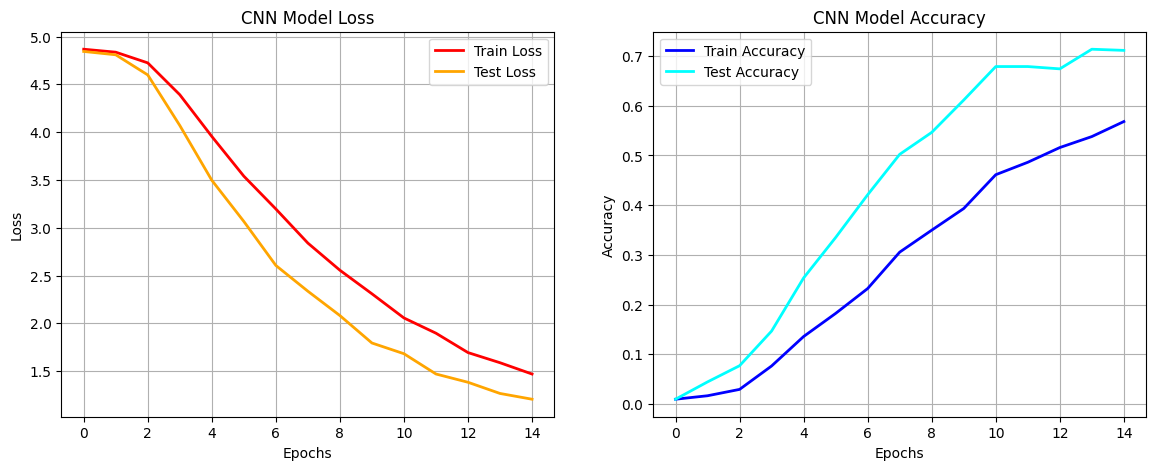

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# ==========================================
# 1. Data Loading, Merging & Splitting
# ==========================================
def load_and_merge_data(base_path):
    """
    Reads images from 'train' and 'test' folders, merges them, 
    resizes to 64x64, and extracts labels based on folder names.
    """
    X_images = []
    y_labels = []
    
    # Looping through train and test folders to merge data
    for split in ['train', 'test']:
        split_path = os.path.join(base_path, split)
        if not os.path.exists(split_path):
            continue
            
        for class_name in os.listdir(split_path):
            class_path = os.path.join(split_path, class_name)
            if os.path.isdir(class_path):
                for img_name in os.listdir(class_path):
                    img_path = os.path.join(class_path, img_name)
                    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    if img is not None:
                        img = cv2.resize(img, (64, 64)) # Resize for fast basic training
                        X_images.append(img)
                        y_labels.append(class_name)
                        
    return np.array(X_images), np.array(y_labels)

# UPDATED: Kaggle dataset path based on your exact location
dataset_path = '/kaggle/input/datasets/robinreni/signature-verification-dataset/sign_data'
print("Loading and merging dataset...")
X_full, y_full_text = load_and_merge_data(dataset_path)

# Encode text labels into integers
encoder = LabelEncoder()
y_full = encoder.fit_transform(y_full_text)
num_classes = len(np.unique(y_full))

print(f"Total images loaded: {len(X_full)}, Total classes: {num_classes}")

# Fresh Split: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

# ==========================================
# 2. Manual Feature Extraction (HOG) & ML Model
# ==========================================
def extract_hog_features(images):
    """Extracts HOG features from a list of images."""
    features = []
    for img in images:
        fd = hog(img, orientations=8, pixels_per_cell=(8, 8), cells_per_block=(2, 2))
        features.append(fd)
    return np.array(features)

print("Extracting HOG features...")
X_train_hog = extract_hog_features(X_train)
X_test_hog = extract_hog_features(X_test)

# Train a basic Random Forest on manual features
print("Training Random Forest on HOG features...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_hog, y_train)
rf_preds = rf_model.predict(X_test_hog)

print("\n--- Manual Feature Extraction (HOG + Random Forest) ---")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(f"Precision: {precision_score(y_test, rf_preds, average='weighted', zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, rf_preds, average='weighted', zero_division=0):.4f}")
print(f"F1-Measure: {f1_score(y_test, rf_preds, average='weighted', zero_division=0):.4f}\n")

# ==========================================
# 3. CNN Implementation
# ==========================================
# Reshape and normalize data for CNN (Adding channel dimension for Grayscale)
X_train_cnn = X_train.reshape(-1, 64, 64, 1) / 255.0
X_test_cnn = X_test.reshape(-1, 64, 64, 1) / 255.0

# Basic CNN Architecture
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax' if num_classes > 2 else 'sigmoid')
])

loss_fn = 'sparse_categorical_crossentropy' if num_classes > 2 else 'binary_crossentropy'
cnn_model.compile(optimizer='adam', loss=loss_fn, metrics=['accuracy'])

print("Training CNN Model...")
# Train CNN for 15 epochs
history = cnn_model.fit(X_train_cnn, y_train, epochs=15, batch_size=32, validation_data=(X_test_cnn, y_test), verbose=1)

# Predict and Evaluate CNN
cnn_probs = cnn_model.predict(X_test_cnn)
cnn_preds = np.argmax(cnn_probs, axis=1) if num_classes > 2 else (cnn_probs > 0.5).astype(int).flatten()

print("\n--- CNN Feature Extraction ---")
print(f"Accuracy: {accuracy_score(y_test, cnn_preds):.4f}")
print(f"Precision: {precision_score(y_test, cnn_preds, average='weighted', zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, cnn_preds, average='weighted', zero_division=0):.4f}")
print(f"F1-Measure: {f1_score(y_test, cnn_preds, average='weighted', zero_division=0):.4f}\n")

# ==========================================
# 4. Plotting Train and Test Metrics
# ==========================================
plt.figure(figsize=(14, 5))

# Plotting Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='red', linewidth=2)
plt.plot(history.history['val_loss'], label='Test Loss', color='orange', linewidth=2)
plt.title('CNN Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Plotting Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Test Accuracy', color='cyan', linewidth=2)
plt.title('CNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.show()